# Template Eksperimen MSML

# 1. Perkenalan Dataset

Dataset yang digunakan dalam penelitian ini adalah **Telco Customer Churn Dataset**, yaitu dataset yang berisi informasi pelanggan perusahaan layanan telekomunikasi beserta status apakah pelanggan tersebut berhenti berlangganan (churn) atau tetap menggunakan layanan yang tersedia. Dataset ini banyak digunakan dalam penelitian dan pengembangan model machine learning untuk kasus klasifikasi churn pelanggan.

Dataset terdiri dari **7.043 data pelanggan** dengan **20 atribut**, yang mencakup karakteristik demografis pelanggan, informasi layanan yang digunakan, kontrak berlangganan, metode pembayaran, lama berlangganan, serta biaya layanan. Variabel target pada dataset ini adalah **Churn**, yang menunjukkan apakah pelanggan berhenti berlangganan (1) atau tetap menjadi pelanggan (0).

Beberapa fitur yang digunakan dalam dataset antara lain:

* **gender** : Jenis kelamin pelanggan.
* **SeniorCitizen** : Status pelanggan sebagai warga lanjut usia.
* **Partner** : Status memiliki pasangan.
* **Dependents** : Status memiliki tanggungan.
* **tenure** : Lama berlangganan.
* **PhoneService** : Penggunaan layanan telepon.
* **MultipleLines** : Penggunaan lebih dari satu jalur telepon.
* **InternetService** : Jenis layanan internet yang digunakan.
* **OnlineSecurity** : Penggunaan layanan keamanan online.
* **OnlineBackup** : Penggunaan layanan pencadangan data.
* **DeviceProtection** : Penggunaan layanan perlindungan perangkat.
* **TechSupport** : Penggunaan layanan dukungan teknis.
* **StreamingTV** : Penggunaan layanan streaming TV.
* **StreamingMovies** : Penggunaan layanan streaming film.
* **Contract** : Jenis kontrak pelanggan.
* **PaperlessBilling** : Penggunaan tagihan elektronik.
* **PaymentMethod** : Metode pembayaran yang digunakan.
* **MonthlyCharges** : Biaya bulanan pelanggan.
* **TotalCharges** : Total biaya yang telah dibayarkan pelanggan.
* **Churn** : Status pelanggan berhenti berlangganan atau tidak.

Tujuan analisis pada dataset ini adalah membangun model machine learning yang mampu memprediksi kemungkinan pelanggan melakukan churn berdasarkan karakteristik dan pola penggunaan layanan yang dimiliki. Hasil prediksi tersebut dapat membantu perusahaan telekomunikasi dalam menyusun strategi retensi pelanggan sehingga dapat mengurangi tingkat kehilangan pelanggan dan meningkatkan loyalitas pelanggan.


# 2. Import Library

1. Import Library

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

# 3. Memuat Dataset

2. Data Loading

In [77]:
df = pd.read_csv("../dataset_raw/telco_churn.csv")

print("Jumlah Baris dan Kolom:")
print(df.shape)

df.head()

Jumlah Baris dan Kolom:
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 4. Exploratory Data Analysis (EDA)

Bagian ini berisi pemahaman awal terhadap dataset, statistik deskriptif, distribusi target, visualisasi, dan insight awal.


3. Informasi Dataset

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


4. Statistik Deskriptif

In [79]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


5. Mengecek Missing Value

In [80]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

6. Mengecek Data Duplikat

In [81]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


7. Mengecek Distribusi Target

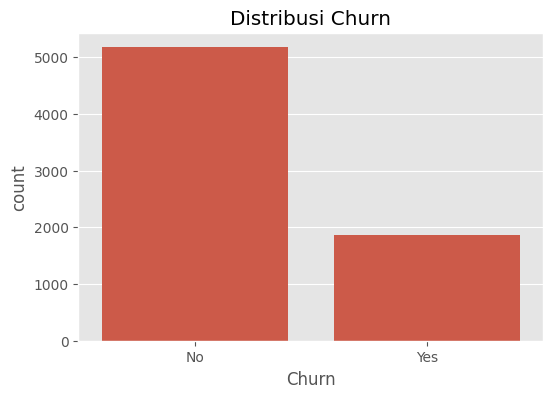

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Distribusi Churn")
plt.show()

8. Persentase Churn

In [83]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

9. Visualisasi Tenure

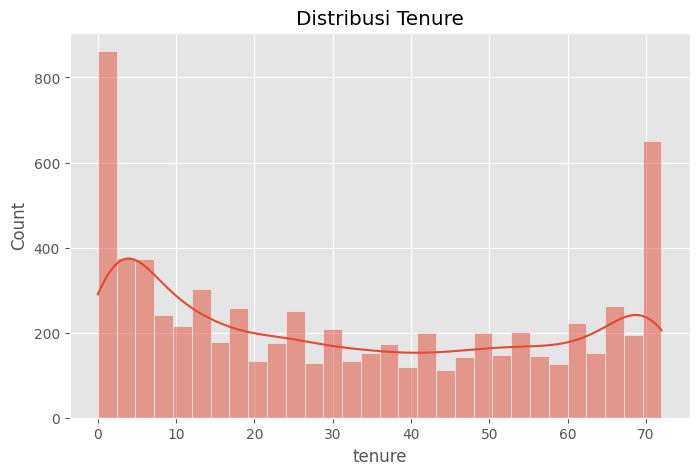

In [84]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title("Distribusi Tenure")
plt.show()

10. Visualisasi Monthly Charges

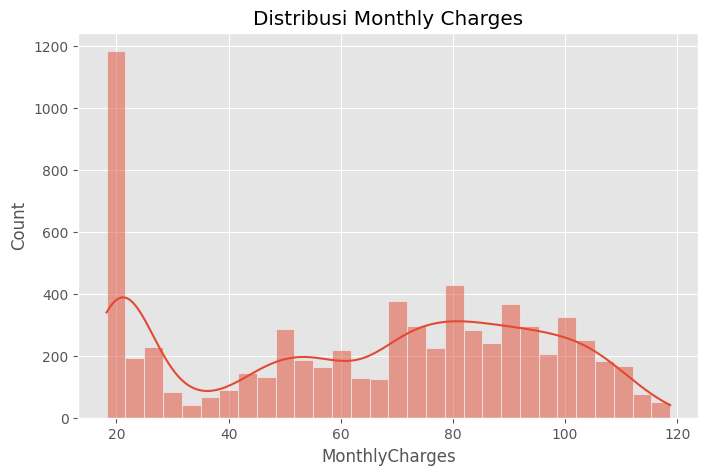

In [85]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    bins=30,
    kde=True
)

plt.title("Distribusi Monthly Charges")
plt.show()

11. Visualisasi Churn Berdasarkan Contract

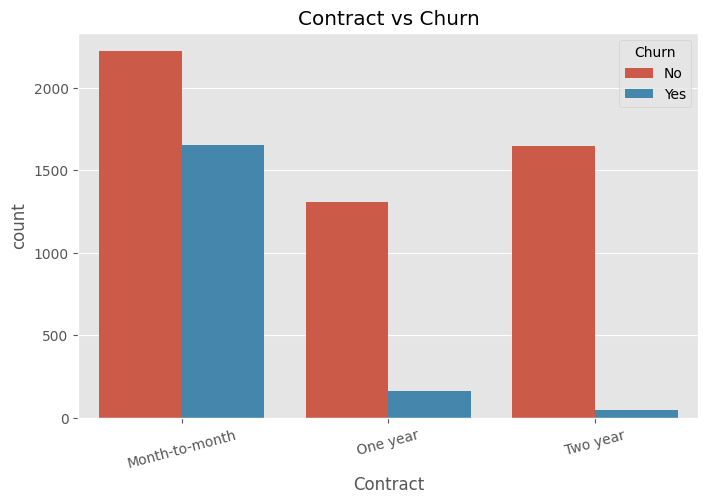

In [86]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract vs Churn")
plt.xticks(rotation=15)

plt.show()

12. Visualisasi Churn Berdasarkan Internet Service

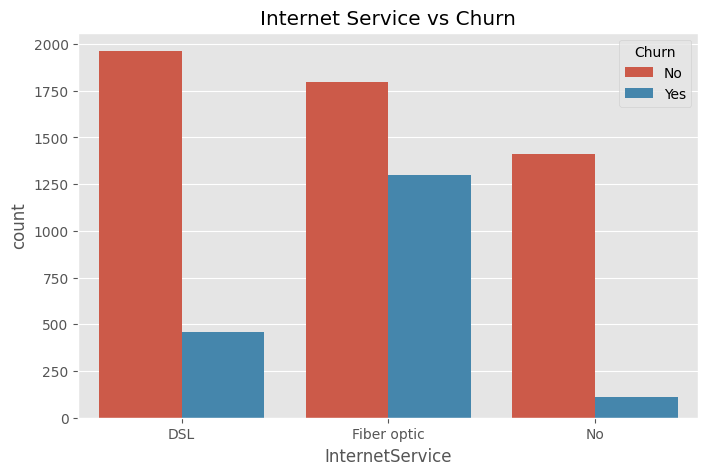

In [87]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

# 5. Data Preprocessing

Tahap pembersihan data, penanganan missing value, encoding, scaling, dan persiapan data sebelum pemodelan.


13. Data Cleaning

In [88]:
df.drop(
    columns=['customerID'],
    inplace=True
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


14. Perbaiki Kolom TotalCharges

Cek tipe data:

In [89]:
df['TotalCharges'].dtype

dtype('O')

Konversi ke numerik:

In [90]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

15. Missing Value Setelah Konversi

In [91]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

16. Mengisi Missing Value

In [92]:
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

Verifikasi :

In [93]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

17. Encoding Data Kategorikal

In [94]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(
    include='object'
).columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

18. Label Encoding

In [95]:
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


19. Correlation Heatmap

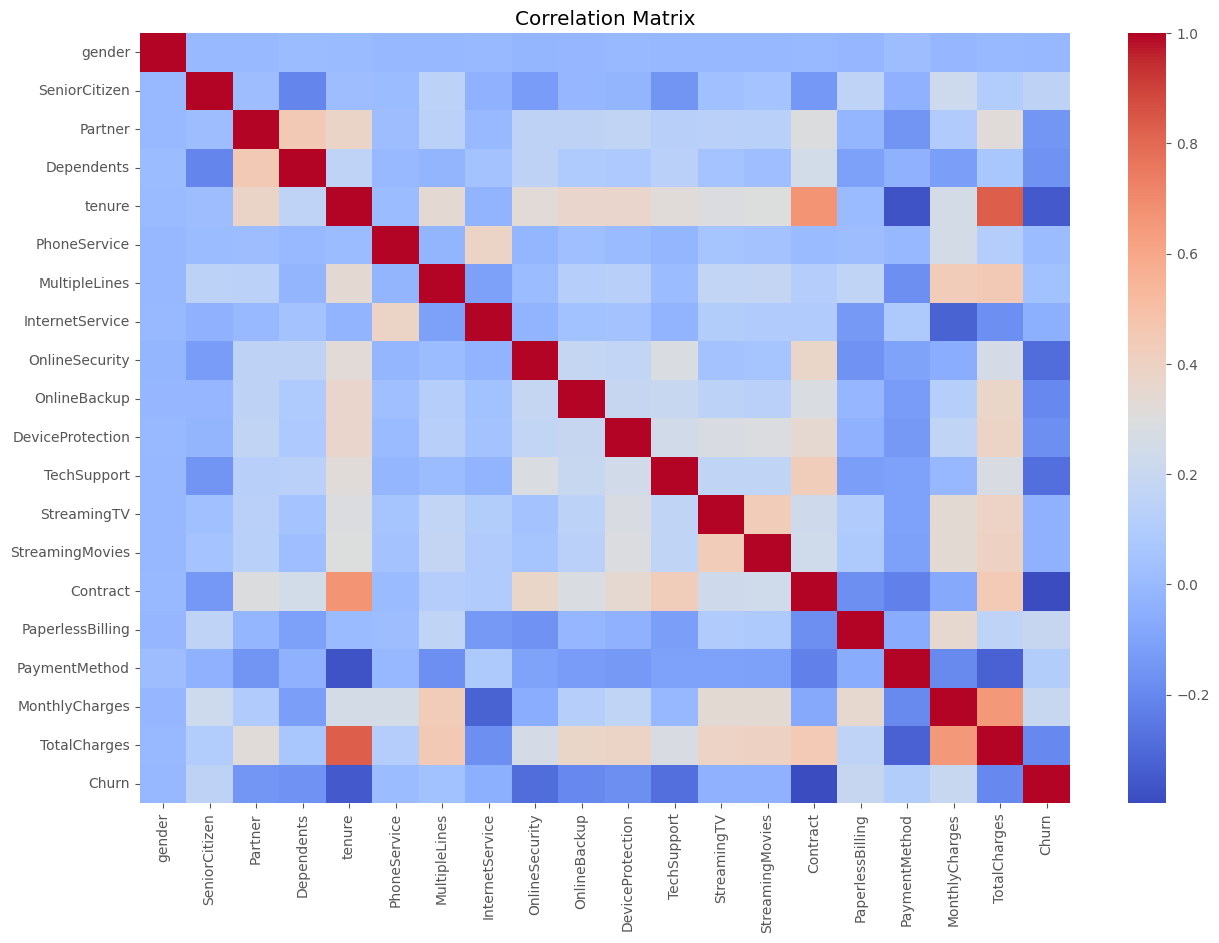

In [96]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

20. Feature Scaling

In [97]:
scaler = StandardScaler()

numerical_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

df[numerical_columns] = scaler.fit_transform(
    df[numerical_columns]
)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.994242,0
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.173244,0
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.959674,1
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.194766,0
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.940470,1


21. Verifikasi Dataset

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int32  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     7043 non-null   int32  
 7   InternetService   7043 non-null   int32  
 8   OnlineSecurity    7043 non-null   int32  
 9   OnlineBackup      7043 non-null   int32  
 10  DeviceProtection  7043 non-null   int32  
 11  TechSupport       7043 non-null   int32  
 12  StreamingTV       7043 non-null   int32  
 13  StreamingMovies   7043 non-null   int32  
 14  Contract          7043 non-null   int32  
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   int32  


22. Simpan Dataset Hasil Preprocessing

In [99]:
df.to_csv(
    "telco_churn_preprocessing.csv",
    index=False
)

print("Dataset berhasil disimpan")

Dataset berhasil disimpan


23. Cek Hasil Dataset

In [100]:
processed_df = pd.read_csv(
    "telco_churn_preprocessing.csv"
)

processed_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.277445,0,1,0,0,2,0,0,0,0,0,1,2,-1.160323,-0.994242,0
1,1,0,0,0,0.066327,1,0,0,2,0,2,0,0,0,1,0,3,-0.259629,-0.173244,0
2,1,0,0,0,-1.236724,1,0,0,2,2,0,0,0,0,0,1,3,-0.362660,-0.959674,1
3,1,0,0,0,0.514251,0,1,0,2,0,2,2,0,0,1,0,0,-0.746535,-0.194766,0
4,0,0,0,0,-1.236724,1,0,1,0,0,0,0,0,0,0,1,2,0.197365,-0.940470,1


# 6. Membangun Model

Pada tahap ini dilakukan pembangunan model machine learning untuk memprediksi pelanggan yang berpotensi melakukan churn. Dataset yang telah melalui tahap preprocessing dibagi menjadi data latih dan data uji menggunakan rasio 80:20.

Model yang digunakan adalah Random Forest Classifier karena memiliki kemampuan yang baik dalam menangani data kategorikal hasil encoding serta mampu mengurangi risiko overfitting melalui mekanisme ensemble learning.

In [101]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (5634, 19)
Test : (1409, 19)


In [102]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Training selesai")

Training selesai


# 7. Evaluasi Model

Evaluasi dilakukan menggunakan beberapa metrik klasifikasi yaitu Accuracy, Precision, Recall, dan F1-Score untuk mengetahui performa model dalam memprediksi churn pelanggan.lain yang relevan.


In [103]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7899
Precision: 0.6345
Recall   : 0.4920
F1 Score : 0.5542


In [104]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



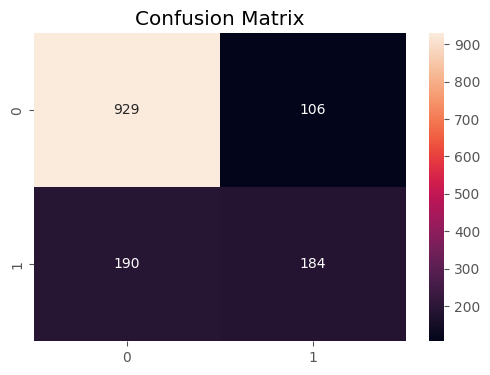

In [105]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# 8. Eksperimen MLflow

Eksperimen dilakukan menggunakan MLflow untuk mencatat parameter model, metrik evaluasi, dan artefak yang dihasilkan selama proses training sehingga eksperimen dapat direproduksi dengan mudah.


### Implementasi MLflow

Proses experiment tracking pada proyek ini dilakukan menggunakan MLflow yang diimplementasikan pada file modelling.py. MLflow digunakan untuk mencatat parameter model, metrik evaluasi, serta artefak yang dihasilkan selama proses pelatihan model.

Parameter yang dicatat meliputi konfigurasi model Random Forest, sedangkan metrik yang dicatat meliputi Accuracy, Precision, Recall, dan F1-Score.

### Hasil Tracking MLflow

Berikut merupakan dashboard MLflow yang menampilkan parameter dan metrik

Dashboard MLflow berhasil mencatat parameter dan metrik hasil eksperimen. Bukti dashboard disertakan pada file screenshot_dashboard.jpg.
hasil eksperimen.

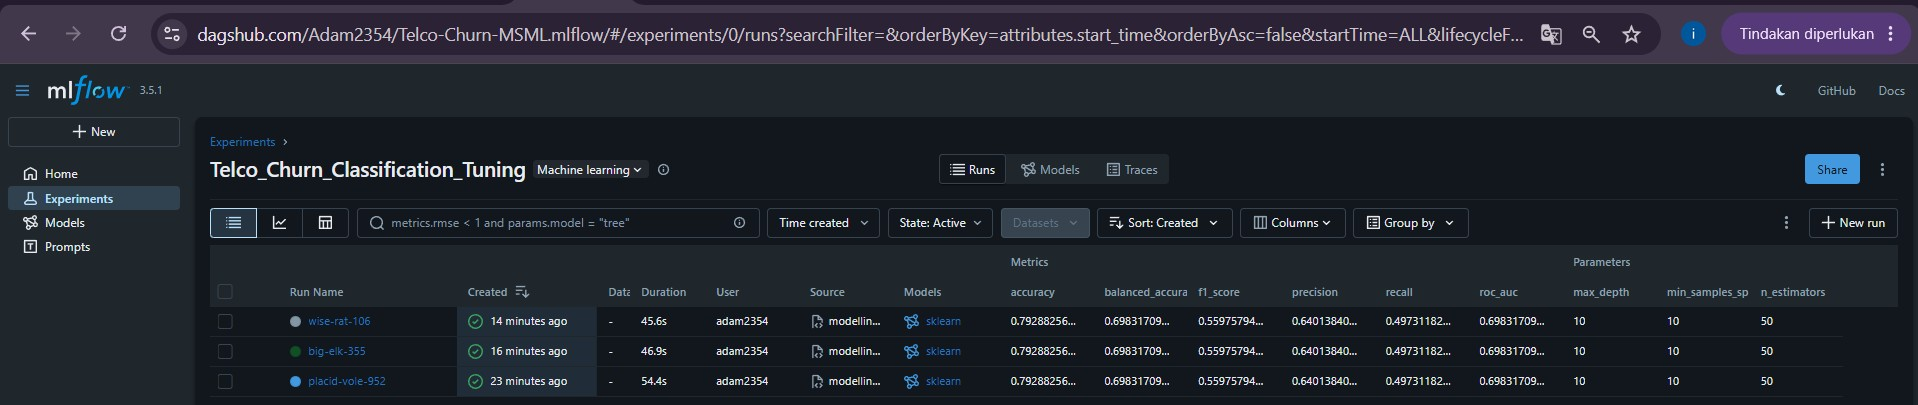

In [106]:
from IPython.display import Image, display

display(Image(filename="../../Membangun Model/screenshoot_dashboard.jpg"))

### Artifact Logging

MLflow berhasil menyimpan artefak berupa:

- model.pkl
- classification_report.txt
- confusion_matrix.png
- feature_importance.csv

Bukti penyimpanan artefak disertakan pada file screenshot_bukti_artifak_clear.jpg.

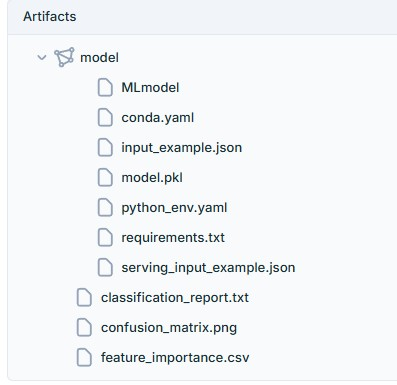

In [107]:
from IPython.display import Image, display

display(Image(filename="../../Membangun Model/screenshoot_bukti artifak_clear.jpg"))

### Ringkasan Eksperimen

Berdasarkan hasil tracking menggunakan MLflow, seluruh parameter, metrik evaluasi, dan artefak berhasil dicatat dengan baik. Hal ini menunjukkan bahwa proses eksperimen telah terdokumentasi secara sistematis sehingga mendukung prinsip reproducibility dalam implementasi MLOps.

# 9. Kesimpulan

Berdasarkan hasil eksperimen yang telah dilakukan pada dataset Telco Customer Churn, diperoleh beberapa kesimpulan sebagai berikut:

1. Dataset berhasil melalui tahapan preprocessing yang meliputi penghapusan fitur yang tidak relevan (customerID), penanganan missing value pada kolom TotalCharges menggunakan median, encoding fitur kategorikal menggunakan Label Encoding, serta standarisasi fitur numerik menggunakan StandardScaler.

2. Dataset hasil preprocessing berhasil disimpan dalam file `telco_churn_preprocessing.csv` dan digunakan pada tahap pelatihan model machine learning.

3. Model Random Forest berhasil dilatih menggunakan data pelanggan yang telah diproses dan mampu melakukan klasifikasi churn pelanggan dengan performa yang baik berdasarkan metrik Accuracy, Precision, Recall, dan F1-Score.

4. Proses eksperimen telah didokumentasikan menggunakan MLflow untuk mencatat parameter model, metrik evaluasi, serta artefak yang dihasilkan selama pelatihan model.

5. Artefak yang berhasil disimpan meliputi model hasil pelatihan, classification report, confusion matrix, dan feature importance sehingga eksperimen dapat direproduksi dengan lebih mudah.

6. Model yang dibangun dapat dimanfaatkan sebagai pendukung pengambilan keputusan bagi perusahaan telekomunikasi dalam mengidentifikasi pelanggan yang berpotensi melakukan churn sehingga strategi retensi pelanggan dapat dilakukan secara lebih efektif.